## EDA on data from HR project from spring 25

In [ ]:
# establishing duckdb


In [46]:
import requests
import duckdb

con = duckdb.connect("jobads.duckdb")

# 1. Create clean table (your structure)
con.execute("""
CREATE TABLE IF NOT EXISTS job_ads (
    id TEXT,
    headline TEXT,
    employer_name TEXT,
    published TEXT
)
""")

# 2. Call API
r = requests.get(
    "https://jobsearch.api.jobtechdev.se/search",
    headers={"accept": "application/json"},
    params={"limit": 100}
)

hits = r.json().get("hits", [])

# 3. Extract only what you want
rows = []
for ad in hits:
    rows.append((
        ad.get("id"),
        ad.get("headline"),
        (ad.get("employer") or {}).get("name"),
        ad.get("publication_date"),
    ))

# 4. Insert clean rows
con.executemany("""
INSERT INTO job_ads VALUES (?, ?, ?, ?)
""", rows)

#con.close()


In [47]:
con.execute("SELECT * FROM job_ads LIMIT 5").fetchdf()


,id,headline,employer_name,published
0,30562135,"Tandhygienist, Folktandvården Origo, Falun",REGION DALARNA,2026-02-04T09:22:55
1,30562133,"Allakando läxhjälp Malmö, privatlärare, Spanska",Allakando AB,2026-02-04T09:22:50
2,30562153,Engineering Manager Naval AI & Autonomy,SAAB AB,2026-02-04T09:22:25
3,30562131,Universitetslektor i rättsvetenskap inom civil...,Linnéuniversitetet,2026-02-04T09:22:15
4,30562105,Timanställd lagerarbete,Lobomatic AB,2026-02-04T09:22:00


In [48]:
import requests
import pandas as pd

r = requests.get(
    "https://jobsearch.api.jobtechdev.se/search",
    headers={"accept": "application/json"},
    params={"limit": 100}
)

hits = r.json().get("hits", [])

# Normalize JSON into flat table
df = pd.json_normalize(hits)

df.head()


,relevance,id,external_id,original_id,label,webpage_url,logo_url,headline,application_deadline,number_of_vacancies,...,must_have.skills,must_have.languages,must_have.work_experiences,must_have.education,must_have.education_level,nice_to_have.skills,nice_to_have.languages,nice_to_have.work_experiences,nice_to_have.education,nice_to_have.education_level
0,0.0,30563297,NaN,None,[],https://arbetsformedlingen.se/platsbanken/anno...,https://arbetsformedlingen.se/rest/agas/api/v1...,Housekeeping,2026-03-06T23:59:59,3,...,[],[],[],[],[],[],[],"[{'weight': 5, 'concept_id': 'PiBg_iBj_qEw', '...",[],[]
1,0.0,30563342,46-559068-8346-100483,None,[],https://arbetsformedlingen.se/platsbanken/anno...,https://arbetsformedlingen.se/rest/agas/api/v1...,Avdelningschef till Älmhult,2026-03-02T23:59:59,2,...,[],[],"[{'weight': 10, 'concept_id': 'pJKs_jnz_qCp', ...",[],[],[],[],[],[],[]
2,0.0,30563320,46-556787-2048-337330-196459,None,[],https://arbetsformedlingen.se/platsbanken/anno...,https://arbetsformedlingen.se/rest/agas/api/v1...,Farmaceut till Kronans Apotek Svartbäcken VC,2026-03-15T23:59:59,1,...,[],[],"[{'weight': 10, 'concept_id': 'pAdE_uVY_JrR', ...",[],[],[],[],[],[],[]
3,0.0,30563301,NaN,None,[],https://arbetsformedlingen.se/platsbanken/anno...,https://arbetsformedlingen.se/rest/agas/api/v1...,Project Manager,2026-03-06T23:59:59,1,...,[],"[{'weight': 10, 'concept_id': 'zSLA_vw2_FXN', ...","[{'weight': 10, 'concept_id': 'z5AM_ayf_WcL', ...",[],[],[],[],[],[],[]
4,0.0,30563327,46-556405-3964-abe4dca0b41e100137d7825affa20000,None,[],https://arbetsformedlingen.se/platsbanken/anno...,https://arbetsformedlingen.se/rest/agas/api/v1...,Automation & IT-utvecklare,2026-02-26T23:59:59,1,...,[],[],"[{'weight': 10, 'concept_id': 'CQse_CRd_snw', ...",[],[],[],[],[],[],[]


In [49]:
df.columns

Index(['relevance', 'id', 'external_id', 'original_id', 'label', 'webpage_url',
       'logo_url', 'headline', 'application_deadline', 'number_of_vacancies',
       'salary_description', 'access', 'experience_required',
       'access_to_own_car', 'driving_license_required', 'driving_license',
       'application_contacts', 'publication_date', 'last_publication_date',
       'removed', 'removed_date', 'source_type', 'timestamp',
       'description.text', 'description.text_formatted',
       'description.company_information', 'description.needs',
       'description.requirements', 'description.conditions',
       'employment_type.concept_id', 'employment_type.label',
       'employment_type.legacy_ams_taxonomy_id', 'salary_type.concept_id',
       'salary_type.label', 'salary_type.legacy_ams_taxonomy_id',
       'duration.concept_id', 'duration.label',
       'duration.legacy_ams_taxonomy_id', 'working_hours_type.concept_id',
       'working_hours_type.label', 'working_hours_type.legac

In [50]:
df[["occupation_group.label", "occupation.label"]].head()

,occupation_group.label,occupation.label
0,Städare,Hotellstädare
1,Arbetsledare inom tillverkning,"Arbetsledare, tillverkning elektroniska prod."
2,Apotekare,Farmaceut/Apotekare
3,Mjukvaru- och systemutvecklare m.fl.,"Projektledare, IT"
4,Mjukvaru- och systemutvecklare m.fl.,"Civilingenjör, systemutveckling"


In [51]:
df[["headline", "description.text"]].head()


,headline,description.text
0,Housekeeping,Är du en noggrann och serviceinriktad person s...
1,Avdelningschef till Älmhult,Detta är en konfidentiell rekrytering till ett...
2,Farmaceut till Kronans Apotek Svartbäcken VC,Välkommen till vår värld! 👑 Vår vision är en v...
3,Project Manager,"Are you passionate about innovation, emerging ..."
4,Automation & IT-utvecklare,Att utveckla ett hållbart samhälle kräver enga...


In [19]:
import pandas as pd

df["published"] = pd.to_datetime(df["publication_date"])


In [31]:
today = pd.Timestamp.now().normalize()
yesterday_start = today - pd.Timedelta(days=1)
yesterday_end = today

df_yday = df[(df["published"] >= yesterday_start) & (df["published"] < yesterday_end)]


In [52]:
title_col = "occupation.label"


In [53]:
len(df)

100

In [33]:
df["published"] = pd.to_datetime(df["publication_date"])
df["published"] = df["published"].dt.tz_localize("Europe/Stockholm")


In [55]:
df["published"] = pd.to_datetime(df["publication_date"], errors="coerce")
df["published"].isna().sum(), df["published"].min(), df["published"].max()


(np.int64(0),
 Timestamp('2026-02-04 10:41:45'),
 Timestamp('2026-02-04 11:00:55'))

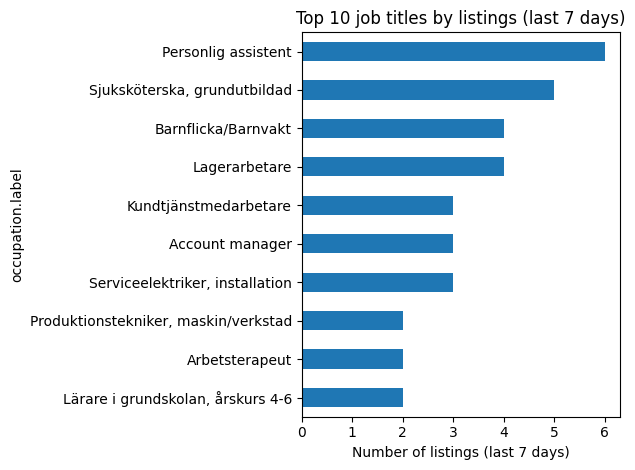

In [57]:
import pandas as pd
import matplotlib.pyplot as plt

# parse time + assert Stockholm tz (no conversion)
df["published"] = pd.to_datetime(df["published"]).dt.tz_localize("Europe/Stockholm")

# last 7 days window
cutoff = pd.Timestamp.now(tz="Europe/Stockholm") - pd.Timedelta(days=7)
df_7d = df[df["published"] >= cutoff]

# top 10 job titles
top10 = df_7d["occupation.label"].value_counts().head(10)

# plot
plt.figure()
top10.sort_values().plot(kind="barh")
plt.xlabel("Number of listings (last 7 days)")
plt.ylabel("occupation.label")
plt.title("Top 10 job titles by listings (last 7 days)")
plt.tight_layout()
plt.show()


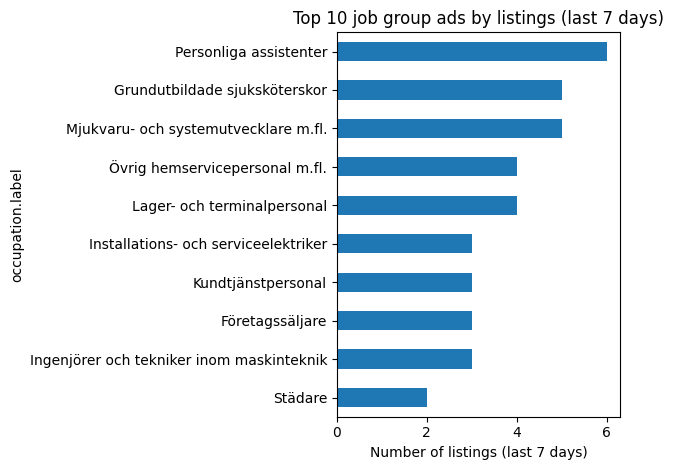

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# parse time + assert Stockholm tz (no conversion)
df["published"] = pd.to_datetime(df["publication_date"]).dt.tz_localize("Europe/Stockholm")

# last 7 days window
cutoff = pd.Timestamp.now(tz="Europe/Stockholm") - pd.Timedelta(days=7)
df_7d = df[df["published"] >= cutoff]

# top 10 job titles
top10 = df_7d["occupation_group.label"].value_counts().head(10)

# plot
plt.figure()
top10.sort_values().plot(kind="barh")
plt.xlabel("Number of listings (last 7 days)")
plt.ylabel("occupation.label")
plt.title("Top 10 job group ads by listings (last 7 days)")
plt.tight_layout()
plt.show()


In [38]:
df = pd.json_normalize(hits)[[
    "id",
    "headline",
    "employer.name",
    "publication_date"
]]

df.columns = ["id", "headline", "employer_name", "published"]

df.head()


,id,headline,employer_name,published
0,30562491,Customer Service Coordinator till storbolag,Hero AB,2026-02-04T09:54:52
1,30562486,"myNanny barnvakt Lund, nanny/barnpassning helt...",YCLA AB,2026-02-04T09:54:45
2,30562514,Sommarjobb på Coop Skillingsfors,Coop Värmland Ekonomisk fören,2026-02-04T09:54:36
3,30562512,Utbildningsledare till kliniskt träningscentrum,REGION UPPSALA,2026-02-04T09:54:29
4,30562508,Sjuksköterska till uppdrag inom slutenvård i L...,Te Crea Care AB,2026-02-04T09:54:15


In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.barh(top_titles["job_title"][::-1], top_titles["num_listings"][::-1])
plt.xlabel("Number of listings (yesterday)")
plt.ylabel("Job title")
plt.title("Top job ads published yesterday")
plt.tight_layout()
plt.show()


In [9]:
df["published"] = pd.to_datetime(df["published"])


In [10]:
# filter 7 days for comparison with 7 days of search hits
last_7_days = df[
    df["published"] >= pd.Timestamp.now() - pd.Timedelta(days=7)
]
last_7_days.head()

,id,headline,employer_name,published
0,30562280,Vikarierande tandsköterska sökes,Motarjemi dental AB,2026-02-04 09:35:00
1,30562282,Befälhavare frigående färja till vikariat på E...,Trafikverket,2026-02-04 09:34:35
2,30562262,Client Specialist,Aros Kapital AB,2026-02-04 09:34:25
3,30562278,Kreditanalytiker - DELTID,Riddermark Bil AB,2026-02-04 09:33:45
4,30561210,Sjuksköterska till Kista,Systrarnas bemanning AB,2026-02-04 09:33:40


In [11]:
# find job description
df.columns

Index(['id', 'headline', 'employer_name', 'published'], dtype='str')